# Task 1 - same-feature baselines

> *"Train a k-NN and/or SVM on `features_val_sample.npz`. This isolates one
> specific question: is our scoring formula the bottleneck, or is the 13D
> feature set itself the real ceiling?"*

**Reported below, as the guide asks:** overall accuracy, per-class accuracy and
confusion matrix, compared directly against SAGE's box 94.7 / can 94.9 /
mug 32.6 / bottle 31.5 / bowl 18.2, overall 78.4.

In [1]:
import sys
from pathlib import Path

# Use the project's src/ modules rather than re-implementing anything here.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import results_io as rio
import viz_style as vs

vs.apply_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

print("Reading results from:", rio.RESULTS_DIR)


Reading results from: C:\Users\suraj\Desktop\ICRA\sage_baseline_experiments\results


In [2]:
task1 = rio.load_task1_summary()
task1 = task1.assign(
    name=lambda d: d["model"].map(rio.pretty),
    split=lambda d: pd.Categorical(
        d["split"], categories=rio.SPLIT_ORDER, ordered=True
    ),
).sort_values(["split", "name"])

rio.as_percent(task1)[
    ["name", "split", "overall_accuracy", "balanced_accuracy"]
    + rio.CLASS_ACCURACY_COLUMNS
].reset_index(drop=True)

,name,split,overall_accuracy,balanced_accuracy,box_accuracy,can_accuracy,mug_accuracy,bottle_accuracy,bowl_accuracy
0,SAGE,video_level,78.4,NaN,94.7,94.9,32.6,31.5,18.2
1,SVM (RBF),random,86.4,64.4,99.4,99.2,28.1,65.8,29.5
2,SVM (linear),random,84.6,60.9,97.9,99.7,32.6,56.2,18.2
3,k-NN,random,92.6,83.3,96.4,98.9,74.2,85.6,61.4
4,SVM (RBF),grouped,85.3,64.8,96.4,98.9,36.0,63.0,29.5
5,SVM (linear),grouped,84.1,60.6,97.7,99.2,30.3,55.5,20.5
6,k-NN,grouped,90.0,79.4,93.3,98.9,65.2,82.9,56.8
7,SVM (RBF),groupkfold,85.6,64.8,96.4,99.4,33.7,65.1,29.5
8,SVM (linear),groupkfold,84.2,61.6,97.9,99.2,33.7,52.1,25.0
9,k-NN,groupkfold,90.3,81.1,92.8,98.9,70.8,81.5,61.4


## The answer: the features are the ceiling

The striking result is not the overall number, it is the **shape**. Plotted
per class, the linear SVM traces SAGE almost exactly on the classes that
matter - and both collapse in the same places.

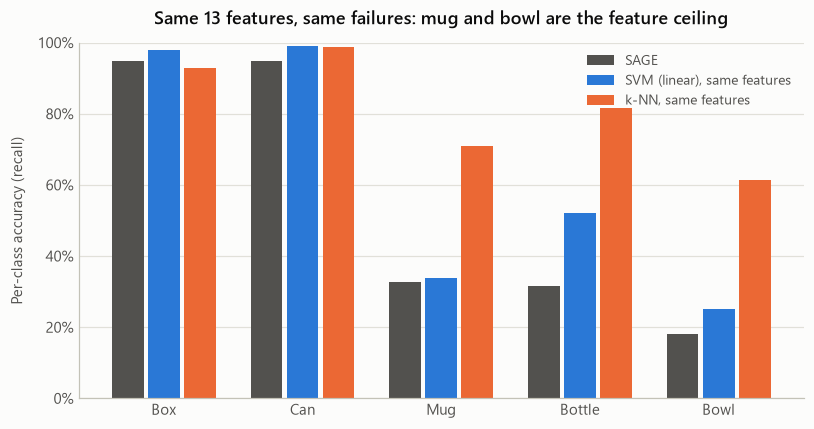

In [3]:
sage = pd.Series(rio.SAGE)
# GroupKFold results - the regime closest to SAGE's own video-level split.
svm = task1[task1["model"] == "svm_linear_groupkfold"].iloc[0]
knn = task1[task1["model"] == "knn_groupkfold"].iloc[0]

series = {
    "SAGE": (sage, vs.SAGE_COLOR),
    "SVM (linear), same features": (svm, vs.BLUE),
    "k-NN, same features": (knn, vs.ORANGE),
}

fig, ax = plt.subplots(figsize=(8.5, 4.2))

vs.grouped_bars(
    ax,
    [c.capitalize() for c in rio.CLASSES],
    {
        name: ([row[f"{c}_accuracy"] * 100 for c in rio.CLASSES], color)
        for name, (row, color) in series.items()
    },
)

vs.percent_axis(ax, "y")
ax.set_ylabel("Per-class accuracy (recall)")
ax.set_title("Same 13 features, same failures: mug and bowl are the feature ceiling")
ax.legend(loc="upper right", ncols=1)
plt.show()

Mug and bowl are where SAGE loses most, and a discriminatively trained SVM on
the identical numbers does **no better**. No scoring change can fix a class the
features cannot separate.

Bottle is the counter-example: same inputs, 55.5% against SAGE's 31.5%.

In [4]:
# How closely does each baseline track SAGE's per-class profile?
sage_profile = np.array([rio.SAGE[f"{c}_accuracy"] for c in rio.CLASSES])

rows = []
for _, row in task1[task1["model"] != "SAGE"].iterrows():
    profile = np.array([row[f"{c}_accuracy"] for c in rio.CLASSES])
    rows.append({
        "model": rio.pretty(row["model"]),
        "split": str(row["split"]),
        "correlation_with_SAGE": np.corrcoef(profile, sage_profile)[0, 1],
        "mean_abs_diff_pp": np.abs(profile - sage_profile).mean() * 100,
    })

pd.DataFrame(rows).sort_values("mean_abs_diff_pp").round(3).reset_index(drop=True)

,model,split,correlation_with_SAGE,mean_abs_diff_pp
0,SVM (linear),random,0.961,6.542
1,SVM (linear),grouped,0.962,7.147
2,SVM (linear),groupkfold,0.979,7.182
3,SVM (RBF),grouped,0.946,10.382
4,SVM (RBF),groupkfold,0.933,10.456
5,SVM (RBF),random,0.920,11.806
6,k-NN,grouped,0.891,25.595
7,k-NN,groupkfold,0.923,27.438
8,k-NN,random,0.896,28.906


The linear SVM sits closest to SAGE's profile by a wide margin, and it does
so under **every** regime - the ranking in that table does not change when
you swap splitters. k-NN is furthest away, and it is also the model most
inflated by leakage, consistent with it succeeding by retrieval rather than
by generalising.

## Confusion matrices

Row-normalised, so each row is the recall breakdown for one true class.

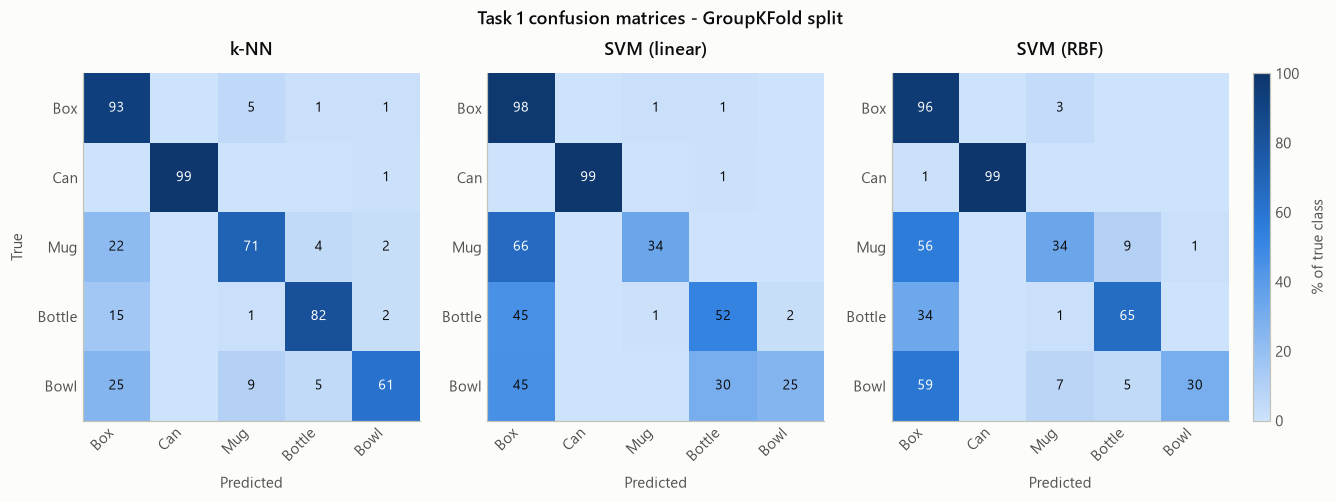

In [5]:
models = ["knn_groupkfold", "svm_linear_groupkfold", "svm_rbf_groupkfold"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.1))

for ax, model in zip(axes, models):
    matrix = rio.load_confusion(model, task="task1", normalize=True)

    image = ax.imshow(
        matrix.values, cmap=vs.SEQUENTIAL, vmin=0, vmax=100, aspect="auto",
    )

    ax.set_xticks(range(len(rio.CLASSES)))
    ax.set_xticklabels([c.capitalize() for c in matrix.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(rio.CLASSES)))
    ax.set_yticklabels([c.capitalize() for c in matrix.index])

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.values[i, j]
            if value < 0.5:
                continue
            # Label inside the fill: pick ink or white by the fill's luminance.
            ax.text(
                j, i, f"{value:.0f}",
                ha="center", va="center", fontsize=9,
                color="white" if value > 55 else vs.INK,
            )

    ax.set_title(rio.pretty(model))
    ax.grid(False)
    ax.set_xlabel("Predicted")
    if ax is axes[0]:
        ax.set_ylabel("True")

fig.colorbar(image, ax=axes, label="% of true class", fraction=0.02, pad=0.02)
fig.suptitle("Task 1 confusion matrices - GroupKFold split", y=1.02, fontsize=12, fontweight="semibold")
plt.show()

The shared failure mode is visible in every panel: **mug, bowl and bottle all
leak into box**. In the 13D space a mug without its handle and a short box are
close to indistinguishable - the radial-profile columns that would separate
them are zero for every non-`can` category by construction.

In [6]:
# Where does each class's error actually go?
matrix = rio.load_confusion("svm_linear_groupkfold", normalize=True)
matrix.round(1)

predicted,box,can,mug,bottle,bowl
true,,,,,
box,97.9,0.0,1.3,0.8,0.0
can,0.0,99.2,0.0,0.6,0.3
mug,66.3,0.0,33.7,0.0,0.0
bottle,45.2,0.0,0.7,52.1,2.1
bowl,45.5,0.0,0.0,29.5,25.0


## Does the conclusion depend on the splitter?

No. Here is every Task 1 model under all three regimes.

In [7]:
regimes = (
    task1[task1["model"] != "SAGE"]
    .assign(split=lambda d: d["split"].astype(str))
    .pivot(index="base_model", columns="split", values="overall_accuracy")
)
regimes.index = [rio.pretty(m) for m in regimes.index]
regimes = (regimes * 100).round(2)
regimes["group vs stratified-group"] = (
    regimes["groupkfold"] - regimes["grouped"]
).round(2)
regimes

split,grouped,groupkfold,random,group vs stratified-group
k-NN,89.99,90.26,92.61,0.27
SVM (linear),84.13,84.22,84.58,0.09
SVM (RBF),85.30,85.57,86.38,0.27


`StratifiedGroupKFold` and `GroupKFold` agree to within a few tenths of a
point on every model. The mug/bowl ceiling, the bottle gap and the ordering
of the three classifiers are all identical under either one - so nothing in
this notebook rests on that choice.

## Caveat

These are within-validation-set cross-validation numbers; SAGE's 78.4% is a
zero-shot transfer from the training videos. The comparison isolates the
*representation*, but the baselines still hold a distributional advantage.
See notebook 00.